In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.problems import make_rastrigin
from src.stopping_criterion import ExactNonconvexCertificate
from src.optimizer import minimize
from src.evaluation import plot_2d_trace

In [2]:
sigma = 0
alpha = 0.6
eps = 1
eta0 = 0.002
# gamma = 0.51
gamma = 0.51

n = 2
x_min = np.zeros(n)
fun, true_grad, stoch_grad, L = make_rastrigin(n, A=10, sigma=sigma)

x0 = np.r_[1, 1] * 5.0


stop_criterion = ExactNonconvexCertificate(fun, sigma, alpha, eps, L, true_grad)

report_interval = 10000
x_avg_t, results = minimize(fun, stoch_grad, None, x0, eta0, gamma, stop_criterion, max_iter=500_000, verbose=True, report_interval=report_interval, true_grad=true_grad, save_trace=True)

[Iter  10000]  F(x)=49.74745 | F_avg(x)=49.74887 | G_avg=   1.124 | Cert=167.02159
[Iter  20000]  F(x)=49.74745 | F_avg(x)=49.74845 | G_avg= 0.79843 | Cert=118.64736
[Iter  30000]  F(x)=49.74745 | F_avg(x)=49.74827 | G_avg= 0.65388 | Cert=97.16808
[Iter  40000]  F(x)=49.74745 | F_avg(x)=49.74816 | G_avg= 0.56756 | Cert=84.34021
[Iter  50000]  F(x)=49.74745 | F_avg(x)=49.74809 | G_avg= 0.50856 | Cert=75.57267
[Iter  60000]  F(x)=49.74745 | F_avg(x)=49.74803 | G_avg= 0.46495 | Cert=69.09233
[Iter  70000]  F(x)=49.74745 | F_avg(x)=49.74799 | G_avg= 0.43102 | Cert=64.05012
[Iter  80000]  F(x)=49.74745 | F_avg(x)=49.74796 | G_avg= 0.40364 | Cert=59.98165
[Iter  90000]  F(x)=49.74745 | F_avg(x)=49.74793 | G_avg= 0.38094 | Cert=56.60864
[Iter 100000]  F(x)=49.74745 | F_avg(x)=49.74790 | G_avg= 0.36173 | Cert=53.75285
[Iter 110000]  F(x)=49.74745 | F_avg(x)=49.74788 | G_avg= 0.34518 | Cert=51.29409
[Iter 120000]  F(x)=49.74745 | F_avg(x)=49.74786 | G_avg= 0.33074 | Cert=49.14799
[Iter 130000] 

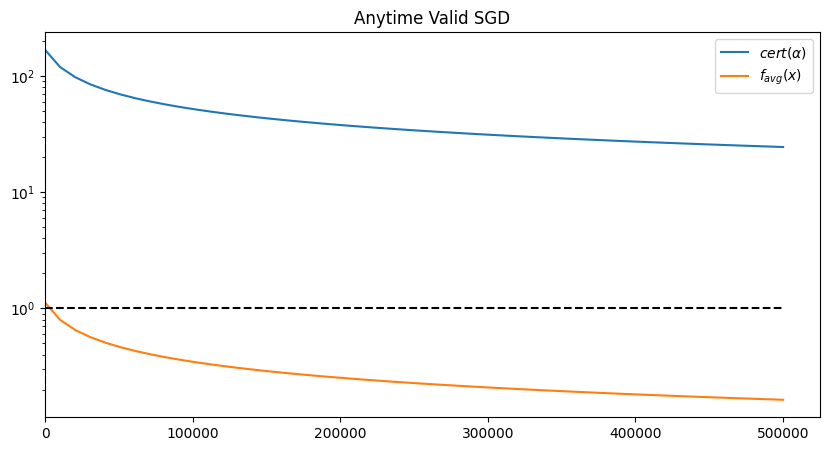

In [3]:
f = results['f']
f_avg = np.r_[results['F_avg']]
g_avg = np.r_[results['G_avg']]
cert = np.r_[results['cert']]

t = np.linspace(1, len(f) * report_interval, len(f))
plt.figure(figsize=(10, 5))
# plt.plot(t, f, label=r"$f_t(x)$")
plt.plot(t, cert, label=r"$cert(\alpha)$")
plt.plot(t, g_avg, label=r"$f_{avg}(x)$")
plt.hlines(y=eps, xmin=0, xmax=np.max(t), linestyles="--", color='black')
plt.xlim(left=0)
plt.yscale('log')
plt.legend(loc='upper right')
plt.title('Anytime Valid SGD')
plt.show()


SGD Trace X range: [4.97, 4.97]
SGD Trace Y range: [4.97, 4.97]
Certified Trace X range: [4.97, 4.97]
Certified Trace Y range: [4.97, 4.97]


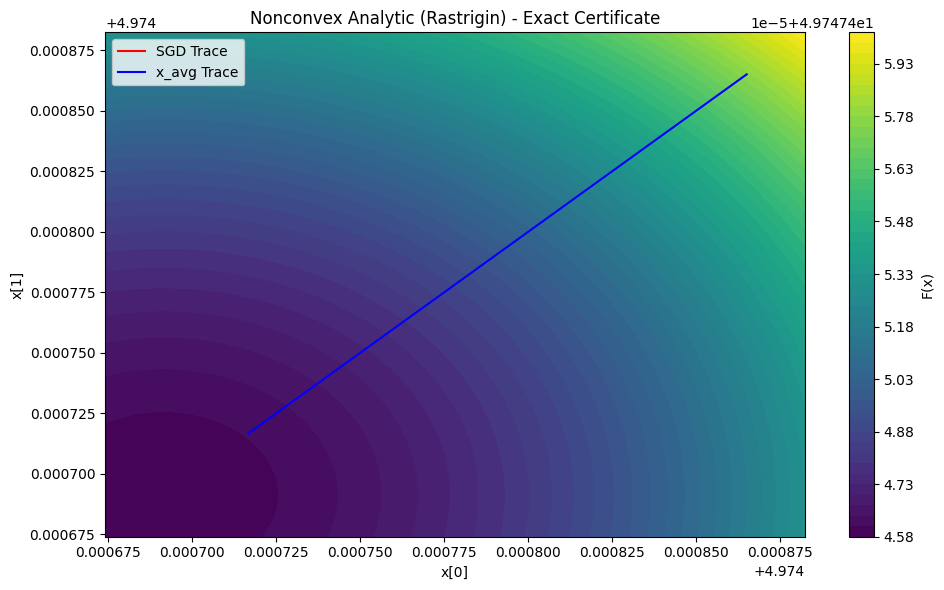

In [4]:
plot_2d_trace(results, fun, plot_type="contours", title="Nonconvex Analytic (Rastrigin) - Exact Certificate")